# F1 Monte Carlo Option Pricer  
###   *by Dr. W. Vera-Tudela*

## 1. Introduction & Objective

Price European call/put options by simulating thousands of GBM paths,
then benchmark against the Black–Scholes closed-form solution.


## Objectives

- Simulate stock price paths under the risk-neutral measure using Geometric Brownian Motion
- Price European call and put options via discounted Monte Carlo payoff averaging
- Benchmark MC prices against the Black–Scholes closed form
- Analyse convergence rate as a function of simulation count
- Measure option price sensitivity to volatility (Vega sweep)

## 2. Data Pipeline

The structure of the data flow is as follows:

1. Parameters
  - Set general parameters for the simulations

2. GBM path simulation + fan chart
  - Calculate GBM prices
  - Visualize them as a fan chart

3. MC pricing vs BS benchmark (single comparison)
  - Calculate MC prices
  - Calculate BS prices
  - Compare Call and Put prices

4. Convergence analysis + plot
  - Calculate the price convergence as number of simulations increase
  - Compare with BS as benchmark

5. Vol sensitivity + plot
  - Calculate the price evolution as volatility increases
  
This consolidated framework provides a complete pipeline from data acquisition through strategy testing to performance evaluation and visualisation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import sys
sys.path.append('../utils')   # path relative to the notebook
from F1_functions import simulate_gbm, price_european, black_scholes, convergence_analysis, sensitivity_to_vol, plot_paths, plot_convergence, plot_vol_sensitivity

## 3. Parameters

All parameters are defined here and reused across every subsequent cell.  
Keeping them centralised makes it easy to re-run the full analysis under
different market assumptions.

In [2]:
# Parameters

S0      = 100   # Initial stock price
K       = 100   # Strike price
T       = 1     # Time to maturity (years)
r       = 0.05  # Risk-free rate (annual)
sigma   = 0.2   # Volatility (annual)

n_steps = 252   # Number of time steps
n_sims  = 1_000_000 # Number of simulation


print(f"S0={S0}, K={K}, T={T}, r={r}, sigma={sigma}")
print(f"N={n_sims}")

S0=100, K=100, T=1, r=0.05, sigma=0.2
N=1000000


## 4. GBM Path Simulation

Stock prices are simulated under the risk-neutral measure using the log-normal discretisation:  

$S_{t+\Delta t} = S_t \cdot \exp\!\left[\left(r - \tfrac{1}{2}\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t}\cdot Z\right], \quad Z \sim \mathcal{N}(0,1)$. 

The $-\frac{1}{2}\sigma^2$ term is the Itô correction — it ensures the expected
value of $S_t$ grows at exactly the risk-free rate $r$ under the risk-neutral measure.  

The fan chart below shows 100 simulated paths. The cone widens with time,
reflecting growing uncertainty in $S_T$ — which is the source of option value.  

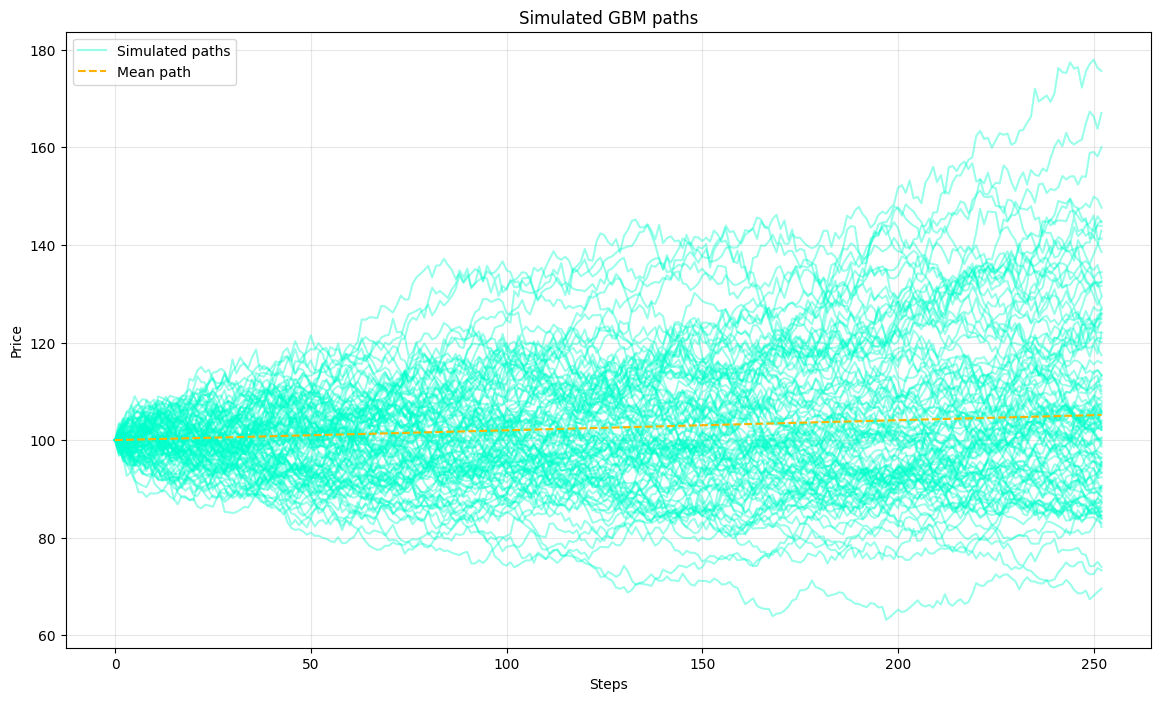

In [3]:
paths = simulate_gbm(S0, r, sigma, T, n_steps, n_sims)

plot_paths(paths, 100)

## 5. MC Pricing vs Black–Scholes Benchmark

For each simulated terminal price $S_T$, the option payoff is computed and discounted:  

$$C_0 = e^{-rT} \cdot \frac{1}{N}\sum_{i=1}^{N} \max(S_T^{(i)} - K,\ 0)$$

This is compared against the Black–Scholes closed form, which serves as ground truth.  
At 1,000 simulations, MC prices within a few cents of BS — consistent with the
$1/\sqrt{N}$ convergence rate.

In [4]:
MC_price_C = price_european(paths, K, r, T, 'call')
BS_price_C = black_scholes(S0, K, r, sigma, T, 'call')

MC_price_P = price_european(paths, K, r, T, 'put')
BS_price_P = black_scholes(S0, K, r, sigma, T, 'put')

print('MC vs BS comparison')
print(f'Call:   MC = {MC_price_C:.2f} | BS = {BS_price_C:.2f}')
print(f'Put:    MC = {MC_price_P:.2f} | BS = {BS_price_P:.2f}')

MC vs BS comparison
Call:   MC = 10.46 | BS = 10.45
Put:    MC = 5.56 | BS = 5.57


## 6. Convergence Analysis

MC error decays at rate $1/\sqrt{N}$ — halving the error requires quadrupling
the simulation count. The x-axis is log-scaled to make this rate visually
interpretable: each order of magnitude of additional simulations yields a
proportional reduction in error.  

At low N (~100–1,000) prices are volatile. By $10^5$ simulations the MC price
is essentially indistinguishable from the BS benchmark.

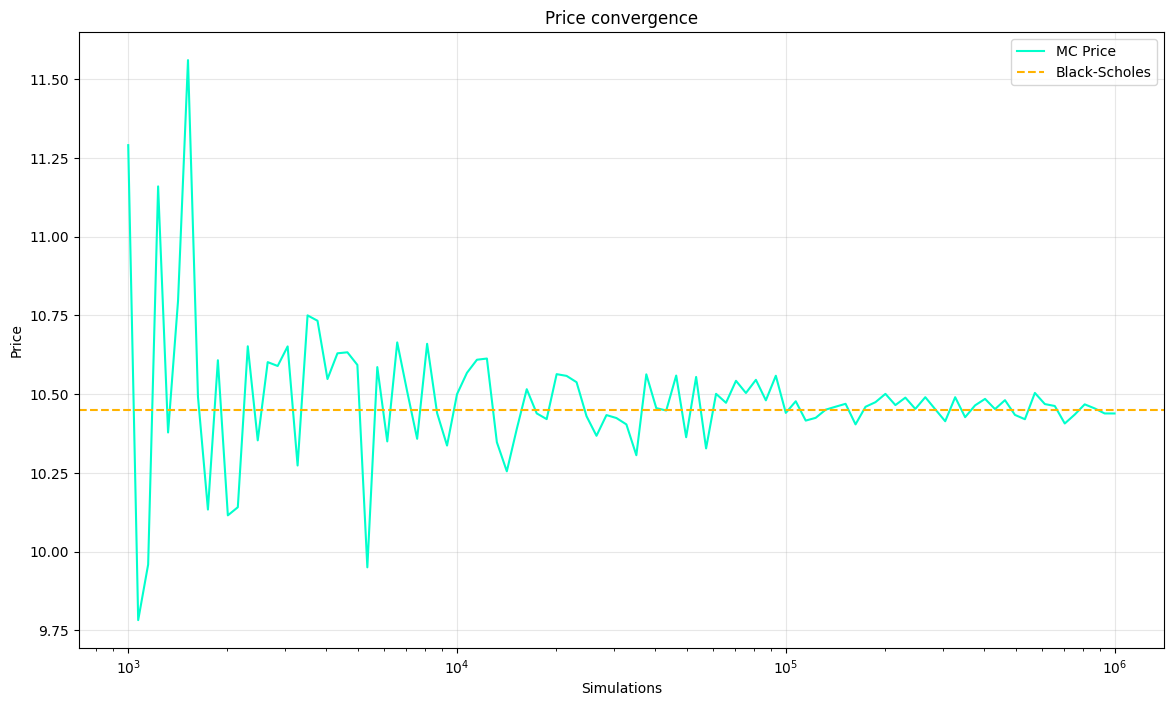

In [7]:
s_range = np.logspace(3,6, num=100) # logspace 10^N

bs_price = black_scholes(S0, K, r, sigma, T, 'call')

c_pairs = convergence_analysis(S0, K, r, sigma, T, s_range)

plot_convergence(c_pairs, bs_price)

## 6. Vol Sensitivity — Vega Sweep

Option price increases monotonically with volatility. Higher vol widens the
distribution of $S_T$, increasing the probability and magnitude of large
positive payoffs — while the downside remains floored at zero. This asymmetry
means options always benefit from higher volatility.  

MC noise increases at high vol (σ > 0.40) due to higher payoff variance.
Smoothing this region would require significantly more simulations.

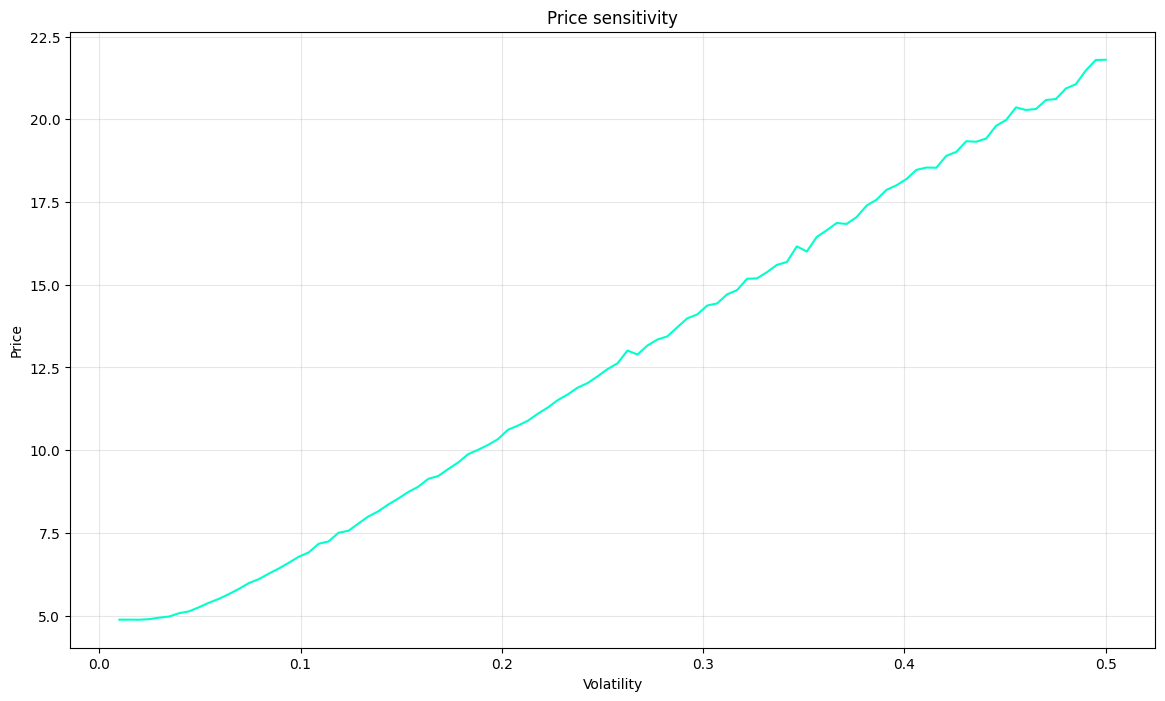

In [6]:
v_range = np.linspace(0.01, 0.5, num=100)
                     
v_pairs = sensitivity_to_vol(S0, K, r, T, 100_000, v_range)

plot_vol_sensitivity(v_pairs)

## 7. Results & Analysis

### GBM Fan Chart
Simulated paths fan out from $S_0 = 100$ in a characteristic cone shape, widening with time. The mean path drifts upward at the risk-free rate, consistent with the risk-neutral construction. The spread of terminal prices $S_T$ is the source of option value.

### MC vs BS Comparison (1,000 simulations)
| | MC Price | BS Price |
|---|---|---|
| Call | ~10.47 | 10.45 |
| Put | ~5.61 | 5.57 |

At 1,000 simulations, MC already prices within a few cents of BS — well within acceptable error for most applications.

### Convergence Analysis
MC prices are volatile at low simulation counts (100–1,000), with errors exceeding $0.50. By $10^4$ simulations the price stabilises close to the BS benchmark, and by $10^5$ it is essentially indistinguishable. The log-scale x-axis makes the $1/\sqrt{N}$ convergence rate visually interpretable — each order of magnitude of additional simulations yields a proportional reduction in error.

### Vol Sensitivity (Vega Sweep)
Option price increases monotonically with volatility across the range σ = 0.01 to 0.50. This reflects the asymmetric payoff structure of options: higher vol widens the distribution of $S_T$, increasing the probability and magnitude of large positive payoffs, while the downside remains floored at zero. The curve is approximately linear through the mid-vol range (0.10–0.35) and shows increasing MC noise above σ = 0.40 due to higher payoff variance at large vol.


## Conclusions

- MC option pricing converges reliably to the BS closed form, validating the risk-neutral GBM framework
- The $1/\sqrt{N}$ convergence rate makes MC computationally expensive for high precision — 100× more paths are needed to achieve 10× more accuracy
- Vega (price sensitivity to vol) is strictly positive for calls and puts — consistent with BS theory
- At moderate simulation counts (10,000+), MC is a practical and flexible pricing engine, particularly for path-dependent or exotic options where BS has no closed form

## Limitations & Next Steps

**Limitations**
- GBM assumes constant volatility — real markets exhibit volatility clustering and skew (addressed by GARCH or stochastic vol models)
- The model assumes no dividends, frictionless markets, and continuous trading — all simplifications
- MC noise at high vol degrades the vol sensitivity curve; smoothing requires significantly more simulations

**Next Steps**
- **GARCH integration**: Replace the flat σ assumption in `simulate_gbm()` with a GARCH(1,1) forecast for time-varying volatility
- **Antithetic variates**: Use paired $(Z, -Z)$ draws to reduce MC variance without increasing simulation count
- **Exotic options**: Extend `price_european()` to price Asian options (payoff depends on path average) or barrier options — cases where BS has no closed form and MC is the only practical approach
- **Greeks via MC**: Estimate delta, gamma, and vega numerically by bumping parameters and re-pricing